In [2]:
!pip install -q -U langchain langchain-cohere langchain-community langchain-text-splitters langchain-chroma pypdf chromadb

In [3]:
from google.colab import userdata
key = userdata.get('cohere_key')

## Shared building blocks
+ These shared RAG components (`embeddings`, `llm`, `prompt`, `build_rag_chain`) are defined once here to be reused across all three sections.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from langchain_cohere import CohereEmbeddings, ChatCohere
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# Embeddings
embeddings = CohereEmbeddings(model="embed-v4.0", cohere_api_key=key)

# LLM
llm = ChatCohere(model="command-a-03-2025", temperature=0, cohere_api_key=key)

# RAG Prompt
RAG_SYSTEM_PROMPT = """You are a helpful assistant.
Answer the user's question using ONLY the provided context.
Do not use outside knowledge.
Do not guess.
Do not fabricate information.
If the answer cannot be found in the provided context,
say exactly:
"I don't know."

Context:
{context}

Question:
{question}"""

prompt = ChatPromptTemplate.from_template(RAG_SYSTEM_PROMPT)

# Build LCEL RAG Chain
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

def build_rag_chain(retriever):
    """Build an LCEL RAG chain on top of a given retriever."""
    return (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

## Test the RAG with Your Own CV

In [6]:
from google.colab import files
uploaded = files.upload()

Saving Ahmed osman - CV.pdf to Ahmed osman - CV.pdf


In [7]:
from langchain_community.document_loaders import PyPDFLoader

cv_path = next(iter(uploaded.keys()))

cv_loader = PyPDFLoader(cv_path)
cv_documents = cv_loader.load()

print("File:", cv_path)
print("Number of pages:", len(cv_documents))

/tmp/ipykernel_2081/2642369087.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


File: Ahmed osman - CV.pdf
Number of pages: 2


In [8]:
print(cv_documents[0].page_content[:80])
print("\nMetadata of first page:")
print(cv_documents[0].metadata)

AHMED MOHAMED OSMAN
Phone-Alt +20168746946 | Envelope ahmedosman112200@gmail.com

Metadata of first page:
{'producer': 'LuaTeX-1.21.0', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-05-30T23:10:32+00:00', 'author': '', 'keywords': '', 'moddate': '2026-05-30T23:10:32+00:00', 'ptex.fullbanner': 'This is LuaHBTeX, Version 1.21.0 (TeX Live 2025)', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'Ahmed osman - CV.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}


+ Split, Embed, Store, Retrieve

In [9]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma

cv_splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100)
cv_chunks = cv_splitter.split_documents(cv_documents)

print("Number of chunks:", len(cv_chunks))

cv_vectorstore = Chroma.from_documents(
    documents=cv_chunks,
    embedding=embeddings,
    collection_name="part1_cv"
)

cv_retriever = cv_vectorstore.as_retriever(search_kwargs={"k": 5})
cv_rag_chain = build_rag_chain(cv_retriever)

Number of chunks: 7


+ Test RAG Questions

In [11]:
cv_questions = [
    "What are my main technical skills?",
    "What machine learning experience do I have?",
    "What projects are mentioned in my CV?",
    "What programming languages do I know?",
    "What training or internships have I completed?",
]

for question in cv_questions:
    answer = cv_rag_chain.invoke(question)
    print("Q:", question)
    print("A:", answer)
    print("-" * 80)

Q: What are my main technical skills?
A: Your main technical skills, as outlined in the provided context, are:

- **Programming Languages**: Python, C++, SQL  
- **Concepts**: Machine Learning, Data Analysis, Object-Oriented Programming (OOP), Data Structures and Algorithms (DSA), Statistics, Probability  
- **Tools & Libraries**: Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn, Jupyter, Git, GitHub  
- **Frameworks & Platforms**: Flutter (used in academic projects)  
- **Technical Reading & Practice**: Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow; Kaggle notebooks for data analysis and machine learning workflows.  

These skills are directly mentioned in the "SKILLS," "TECHNICAL READING," and "PROJECTS" sections of the context.
--------------------------------------------------------------------------------
Q: What machine learning experience do I have?
A: Based on the provided context, your machine learning experience includes:

1. **Kaggle Notebooks Practice**

+ Test Unknown Questions

In [12]:
question = "What is Ahmed's favorite football team?"

answer = cv_rag_chain.invoke(question)
print("Question:", question)
print("Answer:", answer)

Question: What is Ahmed's favorite football team?
Answer: I don't know.


------------------

## Query the Book with RAG

In [13]:
uploaded_book = files.upload()
book_path = next(iter(uploaded_book.keys()))

book_loader = PyPDFLoader(book_path)
book_documents = book_loader.load()

print("File:", book_path)
print("Number of pages:", len(book_documents))

Saving Natural Language Processing with Transformers Building Language Applications with Hugging Face by Lewis Tunstall  Leandro von Werra  Thomas Wolf.pdf to Natural Language Processing with Transformers Building Language Applications with Hugging Face by Lewis Tunstall  Leandro von Werra  Thomas Wolf.pdf
File: Natural Language Processing with Transformers Building Language Applications with Hugging Face by Lewis Tunstall  Leandro von Werra  Thomas Wolf.pdf
Number of pages: 479


+ Chunking Experiment

In [18]:
import time

def build_book_retriever(chunk_size_value, chunk_overlap_value=100, k=5, batch_size=20):
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size_value,chunk_overlap=chunk_overlap_value)
    chunks = splitter.split_documents(book_documents)

    vectorstore = Chroma(collection_name=f"part2_book_cs_{chunk_size_value}", embedding_function=embeddings)

    for i in range(0, len(chunks), batch_size):
        batch = chunks[i:i + batch_size]
        vectorstore.add_documents(batch)
        print(f"Processed {min(i + batch_size, len(chunks))}/{len(chunks)} chunks")
        time.sleep(10)
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    return retriever, len(chunks)

book_retriever_500, n_500 = build_book_retriever(500)
print("chunk_size=500 -> chunks:", n_500)


Processed 20/2068 chunks
Processed 40/2068 chunks
Processed 60/2068 chunks
Processed 80/2068 chunks
Processed 100/2068 chunks
Processed 120/2068 chunks
Processed 140/2068 chunks
Processed 160/2068 chunks
Processed 180/2068 chunks
Processed 200/2068 chunks
Processed 220/2068 chunks
Processed 240/2068 chunks
Processed 260/2068 chunks
Processed 280/2068 chunks
Processed 300/2068 chunks
Processed 320/2068 chunks
Processed 340/2068 chunks
Processed 360/2068 chunks
Processed 380/2068 chunks
Processed 400/2068 chunks
Processed 420/2068 chunks
Processed 440/2068 chunks
Processed 460/2068 chunks
Processed 480/2068 chunks
Processed 500/2068 chunks
Processed 520/2068 chunks
Processed 540/2068 chunks
Processed 560/2068 chunks
Processed 580/2068 chunks
Processed 600/2068 chunks
Processed 620/2068 chunks
Processed 640/2068 chunks
Processed 660/2068 chunks
Processed 680/2068 chunks
Processed 700/2068 chunks
Processed 720/2068 chunks
Processed 740/2068 chunks
Processed 760/2068 chunks
Processed 780/20

In [20]:
book_retriever, _ = build_book_retriever(800)
book_rag_chain = build_rag_chain(book_retriever)

book_questions = [
    "What is the main topic of the book?",
    "What are the key concepts introduced in the first chapters?",
    "What examples or case studies are mentioned?",
    "What conclusions or recommendations does the author give?",
    "What terminology is defined in the book?",
]

for question in book_questions:
    answer = book_rag_chain.invoke(question)
    print("Q:", question)
    print("A:", answer)
    print("-" * 80)

Processed 20/1298 chunks
Processed 40/1298 chunks
Processed 60/1298 chunks
Processed 80/1298 chunks
Processed 100/1298 chunks
Processed 120/1298 chunks
Processed 140/1298 chunks
Processed 160/1298 chunks
Processed 180/1298 chunks
Processed 200/1298 chunks
Processed 220/1298 chunks
Processed 240/1298 chunks
Processed 260/1298 chunks
Processed 280/1298 chunks
Processed 300/1298 chunks
Processed 320/1298 chunks
Processed 340/1298 chunks
Processed 360/1298 chunks
Processed 380/1298 chunks
Processed 400/1298 chunks
Processed 420/1298 chunks
Processed 440/1298 chunks
Processed 460/1298 chunks
Processed 480/1298 chunks
Processed 500/1298 chunks
Processed 520/1298 chunks
Processed 540/1298 chunks
Processed 560/1298 chunks
Processed 580/1298 chunks
Processed 600/1298 chunks
Processed 620/1298 chunks
Processed 640/1298 chunks
Processed 660/1298 chunks
Processed 680/1298 chunks
Processed 700/1298 chunks
Processed 720/1298 chunks
Processed 740/1298 chunks
Processed 760/1298 chunks
Processed 780/12

In [21]:
unknown_question = "What is the author's favorite pizza topping?"
answer = book_rag_chain.invoke(unknown_question)

print("Q:", unknown_question)
print("A:", answer)

Q: What is the author's favorite pizza topping?
A: I don't know.


## Multi-PDF RAG

In [ ]:
uploaded_multi = files.upload()
multi_pdf_paths = list(uploaded_multi.keys())

print("Uploaded files:", multi_pdf_paths)

In [ ]:
all_documents = []

for path in multi_pdf_paths:
    loader = PyPDFLoader(path)
    docs = loader.load()
    all_documents.extend(docs)
    print(f"{path}: {len(docs)} pages loaded")

print("\nTotal documents (pages) across all PDFs:", len(all_documents))

In [ ]:
multi_splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100)
multi_chunks = multi_splitter.split_documents(all_documents)

print("Total chunks:", len(multi_chunks))

multi_vectorstore = Chroma.from_documents(
    documents=multi_chunks,
    embedding=embeddings,
    collection_name="part3_multi_pdf"
)

multi_retriever = multi_vectorstore.as_retriever(search_kwargs={"k": 5})
multi_rag_chain = build_rag_chain(multi_retriever)

In [ ]:
def ask_with_sources(question, retriever, rag_chain):
    retrieved_docs = retriever.invoke(question)
    answer = rag_chain.invoke(question)

    print("Q:", question)
    print("A:", answer)
    print("Sources:")
    seen = set()
    for doc in retrieved_docs:
        source = doc.metadata.get("source")
        page = doc.metadata.get("page")
        key = (source, page)
        if key not in seen:
            seen.add(key)
            print(f"  - {source} (page {page})")
    print("-" * 80)

In [ ]:
multi_pdf_questions = [
    "What information is specific to the first document only?",
    "What information is specific to the second document only?",
    "What information is specific to the third document only?",
    "What do these documents have in common?",
    "What is the capital of Australia?",
]
for q in multi_pdf_questions:
    ask_with_sources(q, multi_retriever, multi_rag_chain)

---------------

## Retrieval Evaluation

> **Optional:** Evaluate the Retriever from Part 1 using manually defined ground truth.

- **Precision:** How many retrieved chunks are relevant?
- **Recall:** How many relevant chunks were retrieved?
- **F1 Score:** Balance between Precision and Recall.

> **Note:** These metrics evaluate the Retriever only, not the final LLM answer.

+ Create Ground Truth Dataset


In [22]:
evaluation_data = [
    {
        "question": "What programming languages are mentioned?",
        "relevant_pages": [0, 1]
    },
    {
        "question": "What machine learning experience is mentioned?",
        "relevant_pages": [1, 2]
    },
    {
        "question": "What projects are mentioned?",
        "relevant_pages": [1, 2]
    },
    {
        "question": "What education or training is mentioned?",
        "relevant_pages": [0]
    },
]

In [23]:
def evaluate_retrieval(question, relevant_pages, retriever):
    retrieved_docs = retriever.invoke(question)
    retrieved_pages = [doc.metadata.get("page") for doc in retrieved_docs]

    relevant_set = set(relevant_pages)
    retrieved_unique = set(retrieved_pages)

    tp = len(retrieved_unique & relevant_set)
    fp = len(retrieved_unique - relevant_set)
    fn = len(relevant_set - retrieved_unique)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "question": question,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }

In [24]:
results = [evaluate_retrieval(item["question"], item["relevant_pages"], cv_retriever) for item in evaluation_data]
results_df = pd.DataFrame(results)

results_df


,question,TP,FP,FN,Precision,Recall,F1
0,What programming languages are mentioned?,2,0,0,1.0,1.0,1.000000
1,What machine learning experience is mentioned?,1,1,1,0.5,0.5,0.500000
2,What projects are mentioned?,0,1,2,0.0,0.0,0.000000
3,What education or training is mentioned?,1,1,0,0.5,1.0,0.666667


In [25]:
avg_precision = results_df["Precision"].mean()
avg_recall = results_df["Recall"].mean()
avg_f1 = results_df["F1"].mean()

print("Average Precision:", round(avg_precision, 3))
print("Average Recall:", round(avg_recall, 3))
print("Average F1:", round(avg_f1, 3))

Average Precision: 0.5
Average Recall: 0.625
Average F1: 0.542


In [26]:
def build_retriever_for_chunk_size(chunk_size_value, chunk_overlap_value=100, k=5):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size_value,
        chunk_overlap=chunk_overlap_value
    )
    new_chunks = splitter.split_documents(cv_documents)

    new_vectorstore = Chroma.from_documents(
        documents=new_chunks,
        embedding=embeddings,
        collection_name=f"bonus_cv_cs_{chunk_size_value}"
    )

    new_retriever = new_vectorstore.as_retriever(search_kwargs={"k": k})
    return new_retriever, len(new_chunks)


chunk_size_values = [500, 800, 1200]
chunk_size_results = []

for cs in chunk_size_values:
    exp_retriever, n_chunks = build_retriever_for_chunk_size(cs)

    exp_results = [
        evaluate_retrieval(item["question"], item["relevant_pages"], exp_retriever)
        for item in evaluation_data
    ]
    exp_df = pd.DataFrame(exp_results)

    chunk_size_results.append({
        "chunk_size": cs,
        "num_chunks": n_chunks,
        "avg_precision": exp_df["Precision"].mean(),
        "avg_recall": exp_df["Recall"].mean(),
        "avg_f1": exp_df["F1"].mean(),
    })

chunk_size_results

[{'chunk_size': 500,
  'num_chunks': 10,
  'avg_precision': np.float64(0.625),
  'avg_recall': np.float64(0.625),
  'avg_f1': np.float64(0.625)},
 {'chunk_size': 800,
  'num_chunks': 7,
  'avg_precision': np.float64(0.5),
  'avg_recall': np.float64(0.625),
  'avg_f1': np.float64(0.5416666666666666)},
 {'chunk_size': 1200,
  'num_chunks': 4,
  'avg_precision': np.float64(0.625),
  'avg_recall': np.float64(0.75),
  'avg_f1': np.float64(0.6666666666666666)}]

In [27]:
chunk_size_df = pd.DataFrame(chunk_size_results)
chunk_size_df

,chunk_size,num_chunks,avg_precision,avg_recall,avg_f1
0,500,10,0.625,0.625,0.625000
1,800,7,0.500,0.625,0.541667
2,1200,4,0.625,0.750,0.666667


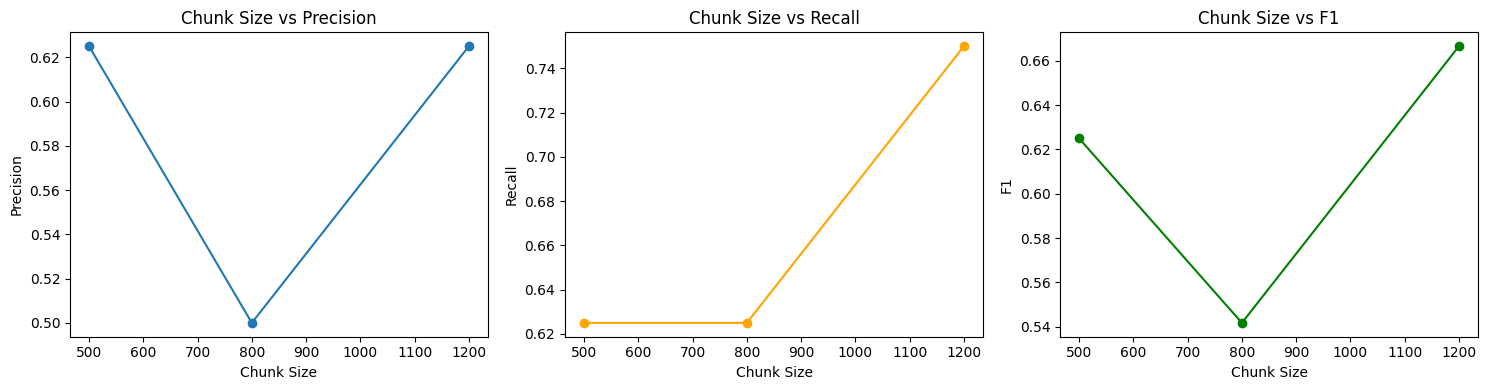

In [28]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(chunk_size_df["chunk_size"], chunk_size_df["avg_precision"], marker="o")
axes[0].set_title("Chunk Size vs Precision")
axes[0].set_xlabel("Chunk Size")
axes[0].set_ylabel("Precision")

axes[1].plot(chunk_size_df["chunk_size"], chunk_size_df["avg_recall"], marker="o", color="orange")
axes[1].set_title("Chunk Size vs Recall")
axes[1].set_xlabel("Chunk Size")
axes[1].set_ylabel("Recall")

axes[2].plot(chunk_size_df["chunk_size"], chunk_size_df["avg_f1"], marker="o", color="green")
axes[2].set_title("Chunk Size vs F1")
axes[2].set_xlabel("Chunk Size")
axes[2].set_ylabel("F1")

plt.tight_layout()
plt.show()

In [29]:
k_base_retriever, _ = build_retriever_for_chunk_size(800, 100, k=5)
k_base_vectorstore_chunks = 800
k_values = [2, 4, 5, 8]
k_results = []

for k in k_values:
    k_retriever = cv_vectorstore.as_retriever(search_kwargs={"k": k})

    k_eval_results = [
        evaluate_retrieval(item["question"], item["relevant_pages"], k_retriever)
        for item in evaluation_data
    ]
    k_eval_df = pd.DataFrame(k_eval_results)

    k_results.append({
        "k": k,
        "avg_precision": k_eval_df["Precision"].mean(),
        "avg_recall": k_eval_df["Recall"].mean(),
        "avg_f1": k_eval_df["F1"].mean(),
    })

k_results

[{'k': 2,
  'avg_precision': np.float64(0.5),
  'avg_recall': np.float64(0.5),
  'avg_f1': np.float64(0.5)},
 {'k': 4,
  'avg_precision': np.float64(0.625),
  'avg_recall': np.float64(0.625),
  'avg_f1': np.float64(0.625)},
 {'k': 5,
  'avg_precision': np.float64(0.5),
  'avg_recall': np.float64(0.625),
  'avg_f1': np.float64(0.5416666666666666)},
 {'k': 8,
  'avg_precision': np.float64(0.625),
  'avg_recall': np.float64(0.75),
  'avg_f1': np.float64(0.6666666666666666)}]

In [30]:
k_df = pd.DataFrame(k_results)
k_df

,k,avg_precision,avg_recall,avg_f1
0,2,0.500,0.500,0.500000
1,4,0.625,0.625,0.625000
2,5,0.500,0.625,0.541667
3,8,0.625,0.750,0.666667


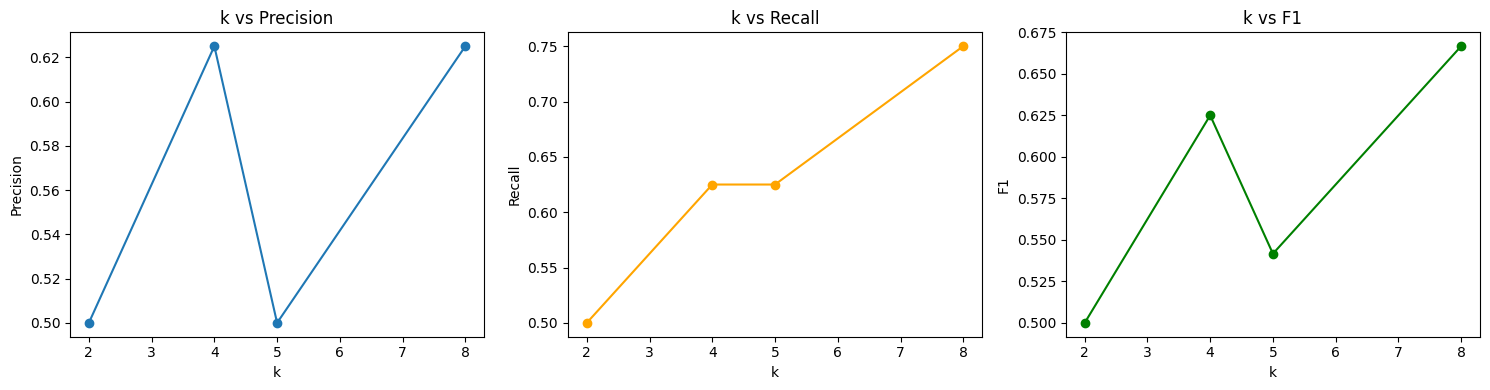

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_df["k"], k_df["avg_precision"], marker="o")
axes[0].set_title("k vs Precision")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Precision")

axes[1].plot(k_df["k"], k_df["avg_recall"], marker="o", color="orange")
axes[1].set_title("k vs Recall")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Recall")

axes[2].plot(k_df["k"], k_df["avg_f1"], marker="o", color="green")
axes[2].set_title("k vs F1")
axes[2].set_xlabel("k")
axes[2].set_ylabel("F1")

plt.tight_layout()
plt.show()

In [32]:
best_chunk_size_row = chunk_size_df.loc[chunk_size_df["avg_f1"].idxmax()]
best_k_row = k_df.loc[k_df["avg_f1"].idxmax()]

print("Best chunk_size (by F1):")
print(best_chunk_size_row)

print("\nBest k (by F1):")
print(best_k_row)

Best chunk_size (by F1):
chunk_size       1200.000000
num_chunks          4.000000
avg_precision       0.625000
avg_recall          0.750000
avg_f1              0.666667
Name: 2, dtype: float64

Best k (by F1):
k                8.000000
avg_precision    0.625000
avg_recall       0.750000
avg_f1           0.666667
Name: 3, dtype: float64


---------------

# <div style="padding:20px; text-align:center; font-size:30px; font-family:Consolas; border-radius:15px; color:#d946ef; box-shadow:0 0 15px rgba(217,70,239,0.25);">༼⁠ ⁠つ⁠ ⁠◕⁠‿⁠◕⁠ ⁠༽⁠つ <b>Thank You!</b></div>